In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
from scipy.stats import ks_2samp

from nrem_analysis.constant import MOUSE_IDS_TTX, PROCESSED_DIR, FIGURES_DIR


REM = "REM (100 ms averaged)"
UP = "NREM (UP states)"
CONTINUOUS_UP = "NREM (continuous intersect UP states)"
ANALYSES = [REM, UP, CONTINUOUS_UP]
CONDITIONS = ["Control", "TTX"]
PALETTE = {"Control": "#d73939", "TTX": "#1d0505"}
VELOCITY_LIMIT = 500
DASHED_STYLE = (0, (5, 5))

## Data preparation

In [3]:
def unwrap_each_epoch(angles):
    """Unwrap degree-valued angles without joining separate epochs."""
    radians = np.deg2rad(angles)
    unwrapped = radians.values.copy()

    for start, end in angles.time_support.values:
        first = np.searchsorted(angles.t, start, side="left")
        last = np.searchsorted(angles.t, end, side="right")
        unwrapped[first:last] = np.unwrap(unwrapped[first:last])

    unwrapped = nap.Tsd(
        t=angles.t, d=unwrapped, time_support=angles.time_support
    )
    return np.rad2deg(unwrapped)


def detect_upstates(spikes):
    bin_size = 0.01
    population_rate = spikes.count(
        bin_size=bin_size, time_units="s"
    ).sum(axis=1) / bin_size
    population_rate = population_rate.smooth(
        std=2 * bin_size, time_units="s"
    )
    threshold = np.percentile(population_rate.values, 80)

    upstates = population_rate.threshold(
        threshold, method="above"
    ).time_support
    upstates = upstates.merge_close_intervals(0.1, time_units="s")
    upstates = upstates.drop_short_intervals(0.04, time_units="s")
    return upstates.drop_long_intervals(2, time_units="s")

In [6]:
def make_rem_table(data_dir, ttx_onset, mouse_id):
    rem_hd = unwrap_each_epoch(nap.load_file(data_dir / "rem_hd.npz"))
    velocity = rem_hd.derivative()

    is_control = rem_hd.time_support.end < ttx_onset
    epochs_by_condition = {
        "Control": rem_hd.time_support[is_control],
        "TTX": rem_hd.time_support[~is_control],
    }

    tables = []
    for condition, epochs in epochs_by_condition.items():
        averaged = velocity.restrict(epochs).bin_average(0.1)
        tables.append(
            pd.DataFrame(
                {
                    "velocity": averaged.values,
                    "condition": condition,
                    "mouse_id": mouse_id,
                    "analysis": REM,
                }
            )
        )

    return pd.concat(tables, ignore_index=True)


def make_sweep_table(head_direction, epochs, ttx_onset, mouse_id, analysis):
    sweeps = head_direction.restrict(epochs)
    epoch_index = np.searchsorted(epochs.start, sweeps.t, side="right") - 1
    split_at = np.flatnonzero(np.diff(epoch_index)) + 1
    angle_chunks = np.split(sweeps.values, split_at)
    time_chunks = np.split(sweeps.t, split_at)

    velocities = []
    conditions = []
    for angles, times in zip(angle_chunks, time_chunks):
        if len(times) < 2:
            continue

        unwrapped = np.unwrap(angles, period=360)
        duration = times[-1] - times[0]
        velocities.append((unwrapped[-1] - unwrapped[0]) / duration)
        condition = "Control" if times[0] < ttx_onset else "TTX"
        conditions.append(condition)

    return pd.DataFrame(
        {
            "velocity": velocities,
            "condition": conditions,
            "mouse_id": mouse_id,
            "analysis": analysis,
        }
    )

In [4]:
def analyze_mouse(mouse_id):
    data_dir = PROCESSED_DIR / "ttx" / mouse_id
    sessions = nap.load_file(data_dir / "sessions.npz")
    ttx_onset = sessions[sessions["label"] == "ttx"].start.item()

    sleep = nap.load_file(data_dir / "sleep.npz")
    hd_units = nap.load_file(data_dir / "hd_units.npz")
    virtual_hd = nap.load_file(data_dir / "virtual_hd.npz")
    virtual_states = nap.load_file(data_dir / "virtual_states.npz")

    homecage = sessions[sessions["label"] == "homecage"]
    nrem = sleep[sleep["state"] == "nrem"].intersect(homecage)
    upstates = detect_upstates(hd_units.restrict(nrem))
    continuous = virtual_states["continuous"].threshold(0.5).time_support

    return pd.concat(
        [
            make_rem_table(data_dir, ttx_onset, mouse_id),
            make_sweep_table(virtual_hd, upstates, ttx_onset, mouse_id, UP),
            make_sweep_table(
                virtual_hd,
                upstates.intersect(continuous),
                ttx_onset,
                mouse_id,
                CONTINUOUS_UP,
            ),
        ],
        ignore_index=True,
    )

## Build one long-form table

In [7]:
results = pd.concat(
    [analyze_mouse(mouse_id) for mouse_id in MOUSE_IDS_TTX],
    ignore_index=True,
)

results.groupby(
    ["analysis", "mouse_id", "condition"]
).size().unstack(fill_value=0)

condition                                       Control    TTX
analysis                              mouse_id                
NREM (UP states)                      116b         6076  39063
                                      119b        12965  39687
                                      83b         17192  12232
                                      85b         11362  12152
NREM (continuous intersect UP states) 116b         2420  20861
                                      119b         6185  18481
                                      83b          7813   4072
                                      85b          7343   7631
REM (100 ms averaged)                 116b         2130  16770
                                      119b         2290  11190
                                      83b         11200  14540
                                      85b          8650   7580

In [8]:
ks_rows = []
for analysis in ANALYSES:
    values = results[results["analysis"] == analysis]
    control = values.loc[values["condition"] == "Control", "velocity"]
    ttx = values.loc[values["condition"] == "TTX", "velocity"]
    test = ks_2samp(control, ttx)
    ks_rows.append(
        {"analysis": analysis, "D": test.statistic, "p": test.pvalue}
    )

ks_results = pd.DataFrame(ks_rows).set_index("analysis")
ks_results

,D,p
analysis,,
REM (100 ms averaged),0.106506,6.148219e-162
NREM (UP states),0.043630,2.631171e-54
NREM (continuous intersect UP states),0.053087,3.725090e-40


## Histograms

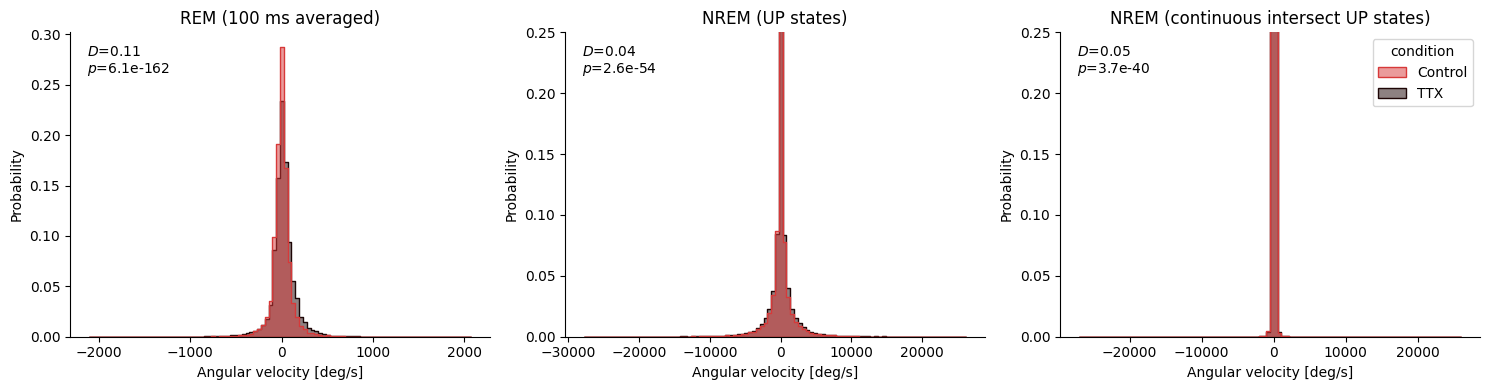

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = results.copy()
for ax, analysis in zip(axes, ANALYSES):
    values = plot_data[plot_data["analysis"] == analysis]
    sns.histplot(
        data=values,
        x="velocity",
        hue="condition",
        hue_order=CONDITIONS,
        palette=PALETTE,
        bins=100,
        stat="probability",
        common_norm=False,
        element="step",
        alpha=0.5,
        legend=analysis == ANALYSES[-1],
        ax=ax,
    )

    test = ks_results.loc[analysis]
    ax.text(
        0.04,
        0.96,
        f"$D$={test['D']:.2f}\n$p$={test['p']:.2g}",
        transform=ax.transAxes,
        va="top",
    )
    ax.set(
        title=analysis,
        xlabel="Angular velocity [deg/s]",
        # xlim=(-5000, 5000),
        # xticks=(-VELOCITY_LIMIT, 0, VELOCITY_LIMIT),
    )
    sns.despine(ax=ax)

axes[1].set_ylim(0, 0.25)
axes[2].set_ylim(0, 0.25)

for ax in axes[1:]:
    ax.set_ylabel("Probability")

fig.tight_layout()

plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_histogram_all.png", format='png', bbox_inches='tight', dpi=320)
plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_histogram_all.svg", format='svg', bbox_inches='tight', dpi=320)


In [26]:
results[results["analysis"] == ANALYSES[2]].max()

velocity                              25999.669994
condition                                      TTX
mouse_id                                       85b
analysis     NREM (continuous intersect UP states)
dtype: object

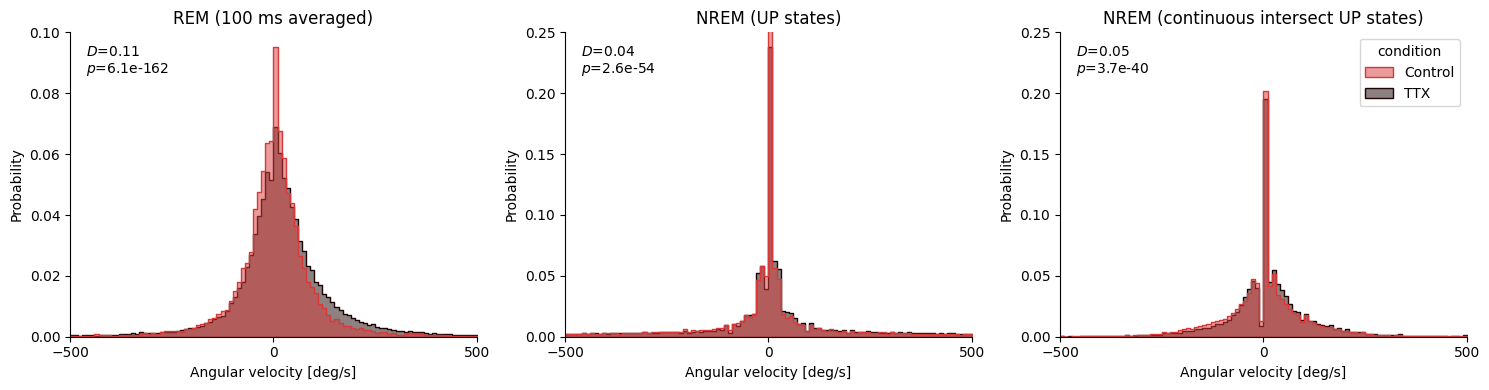

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

plot_data = results[results['velocity'].abs() < VELOCITY_LIMIT]
for ax, analysis in zip(axes, ANALYSES):
    values = plot_data[plot_data["analysis"] == analysis]
    sns.histplot(
        data=values,
        x="velocity",
        hue="condition",
        hue_order=CONDITIONS,
        palette=PALETTE,
        bins=100,
        stat="probability",
        common_norm=False,
        element="step",
        alpha=0.5,
        legend=analysis == ANALYSES[-1],
        ax=ax,
    )

    test = ks_results.loc[analysis]
    ax.text(
        0.04,
        0.96,
        f"$D$={test['D']:.2f}\n$p$={test['p']:.2g}",
        transform=ax.transAxes,
        va="top",
    )
    ax.set(
        title=analysis,
        xlabel="Angular velocity [deg/s]",
        xlim=(-VELOCITY_LIMIT, VELOCITY_LIMIT),
        xticks=(-VELOCITY_LIMIT, 0, VELOCITY_LIMIT),
    )
    sns.despine(ax=ax)

axes[1].set_ylim(0, 0.25)
axes[2].set_ylim(0, 0.25)

for ax in axes[1:]:
    ax.set_ylabel("Probability")

fig.tight_layout()

# plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_histogram.png", format='png', bbox_inches='tight', dpi=320)
# plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_histogram.svg", format='svg', bbox_inches='tight', dpi=320)

## Empirical cumulative distributions

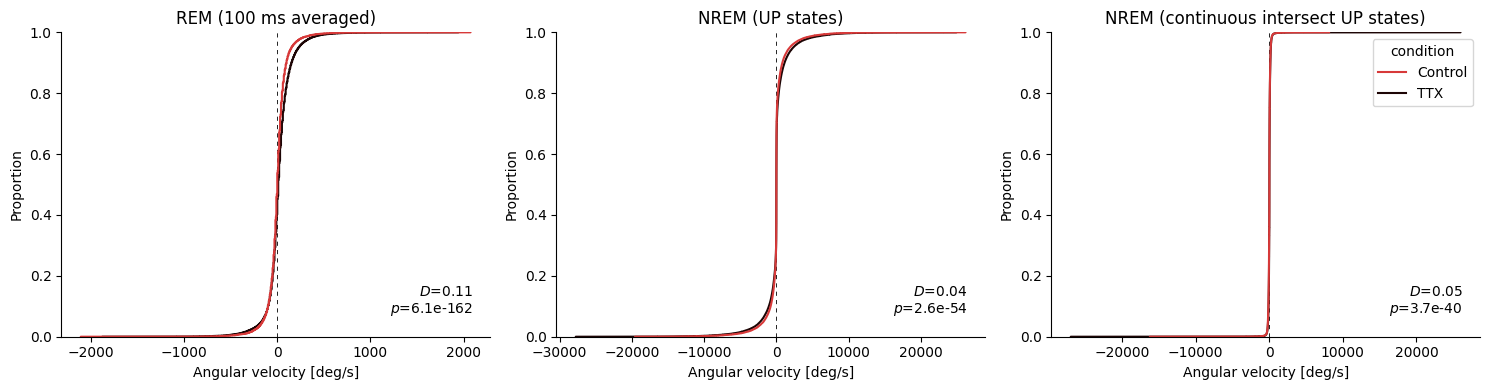

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = results.copy()
for ax, analysis in zip(axes, ANALYSES):
    values = plot_data[plot_data["analysis"] == analysis]
    sns.ecdfplot(
        data=values,
        x="velocity",
        hue="condition",
        hue_order=CONDITIONS,
        palette=PALETTE,
        stat="proportion",
        legend=analysis == ANALYSES[-1],
        ax=ax,
    )

    test = ks_results.loc[analysis]
    ax.text(
        0.96,
        0.06,
        f"$D$={test['D']:.2f}\n$p$={test['p']:.2g}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
    )
    ax.set(
        title=analysis,
        xlabel="Angular velocity [deg/s]",
        # xlim=(-VELOCITY_LIMIT, VELOCITY_LIMIT),
        # xticks=(-VELOCITY_LIMIT, 0, VELOCITY_LIMIT),
    )
    sns.despine(ax=ax)

for ax in axes:
    ax.set_ylabel("Proportion")
    ax.axvline(0, color='k', linestyle=DASHED_STYLE, linewidth=0.6, zorder=0)

fig.tight_layout()

plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_ecdf_all.png", format='png', bbox_inches='tight', dpi=320)
plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_ecdf_all.svg", format='svg', bbox_inches='tight', dpi=320)

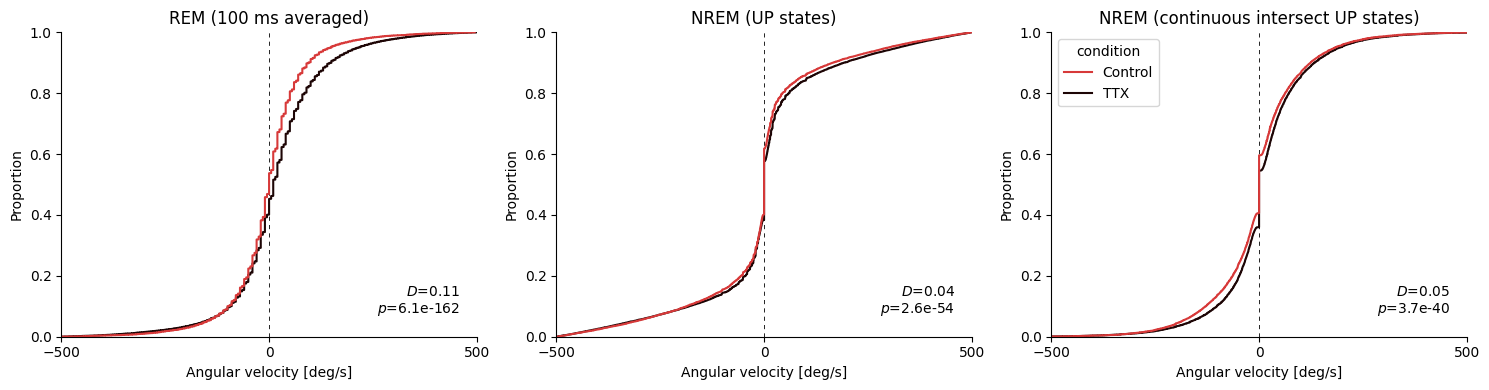

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

plot_data = results[results['velocity'].abs() < VELOCITY_LIMIT]
for ax, analysis in zip(axes, ANALYSES):
    values = plot_data[plot_data["analysis"] == analysis]
    sns.ecdfplot(
        data=values,
        x="velocity",
        hue="condition",
        hue_order=CONDITIONS,
        palette=PALETTE,
        stat="proportion",
        legend=analysis == ANALYSES[-1],
        ax=ax,
    )

    test = ks_results.loc[analysis]
    ax.text(
        0.96,
        0.06,
        f"$D$={test['D']:.2f}\n$p$={test['p']:.2g}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
    )
    ax.set(
        title=analysis,
        xlabel="Angular velocity [deg/s]",
        xlim=(-VELOCITY_LIMIT, VELOCITY_LIMIT),
        xticks=(-VELOCITY_LIMIT, 0, VELOCITY_LIMIT),
    )
    sns.despine(ax=ax)

for ax in axes:
    ax.set_ylabel("Proportion")
    ax.axvline(0, color='k', linestyle=DASHED_STYLE, linewidth=0.6, zorder=0)

fig.tight_layout()

plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_ecdf.png", format='png', bbox_inches='tight', dpi=320)
plt.savefig(FIGURES_DIR / "ttx" / "velocity_distributions_ecdf.svg", format='svg', bbox_inches='tight', dpi=320)